<b>AQI Prediction in Delhi</b>

<i>This project focuses on predicting AQI in Delhi based on several factors. 

The dataset was imported from Kaggle.

Multiple regression models were made in order to find the best one.

Dataset link: https://www.kaggle.com/datasets/kunshbhatia/delhi-air-quality-dataset?select=final_dataset.csv
</i>

1.<u>Data preprocessing</u>

<i>Importing modules</i>

- Imported neccessary modules

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<i>Importing dataset</i>

- Imported dataset

In [158]:
dataset=pd.read_csv(r"C:\Users\Abhijyot Singh Roda\Desktop\Coding Stuff\Python\Projects\Not so random projects\ML Projects\Datasets\FINAL_ITO_DATA.csv")

<i>Information about the dataset</i>

- Got some information about the dataset

In [159]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1461 non-null   int64  
 1   Month           1461 non-null   int64  
 2   Year            1461 non-null   int64  
 3   Holidays_Count  1461 non-null   int64  
 4   Days            1461 non-null   int64  
 5   PM2.5           1461 non-null   float64
 6   PM10            1461 non-null   float64
 7   NO2             1461 non-null   float64
 8   SO2             1461 non-null   float64
 9   CO              1461 non-null   float64
 10  Ozone           1461 non-null   float64
 11  AQI             1461 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 137.1 KB


<i>First 5 rows</i>

- Head of the dataset

In [160]:
dataset.head()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,1,2021,0,5,363.12,459.14,13.24,21.39,6.75,8.54,432
1,2,1,2021,0,6,260.94,325.94,12.76,20.41,4.45,6.77,418
2,3,1,2021,1,7,117.07,144.22,11.25,12.43,3.13,6.04,306
3,4,1,2021,0,1,80.38,109.95,14.40,11.05,3.00,6.78,138
4,5,1,2021,0,2,60.66,83.23,13.28,11.22,2.75,6.33,129


<i>Last 5 rows</i>

- Tail of the dataset

In [161]:
dataset.tail()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
1456,27,12,2024,0,5,154.11,186.61,77.55,17.42,1.39,14.23,357
1457,28,12,2024,0,6,93.38,119.11,68.71,17.14,1.24,14.05,143
1458,29,12,2024,1,7,98.52,128.91,38.12,17.84,0.77,14.63,254
1459,30,12,2024,0,1,94.41,121.45,32.22,13.27,0.96,15.03,178
1460,31,12,2024,0,2,103.02,138.04,41.42,8.64,1.04,13.36,268


<i>Understanding missing values</i>

- Checked if there were any missing values.

In [162]:
print("Number of missing values:")
print(dataset.isnull().sum())

Number of missing values:
Date              0
Month             0
Year              0
Holidays_Count    0
Days              0
PM2.5             0
PM10              0
NO2               0
SO2               0
CO                0
Ozone             0
AQI               0
dtype: int64


<i>Understanding outliers</i>

- Checked if there were any outliers. Although when I consulted Claude, it did say that outliers could be important as they represent real events

In [163]:
numeric_col=dataset.select_dtypes(["int64","float64"]).columns

for col in numeric_col:
    q1=dataset[col].quantile(0.25)
    q3=dataset[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    outliers=((dataset[col]<lower)|(dataset[col]>upper))
    print(f"The number of outliers in {col}: {outliers.sum()}")

The number of outliers in Date: 0
The number of outliers in Month: 0
The number of outliers in Year: 0
The number of outliers in Holidays_Count: 277
The number of outliers in Days: 0
The number of outliers in PM2.5: 56
The number of outliers in PM10: 26
The number of outliers in NO2: 114
The number of outliers in SO2: 121
The number of outliers in CO: 79
The number of outliers in Ozone: 45
The number of outliers in AQI: 0


- Box plot

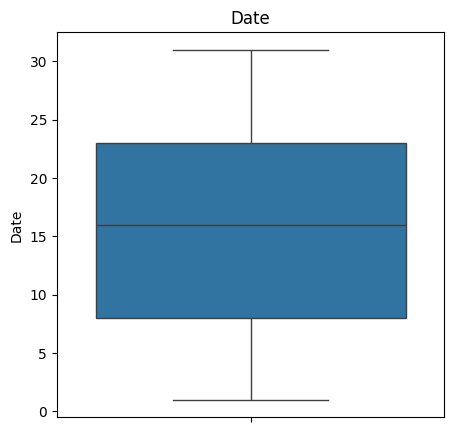

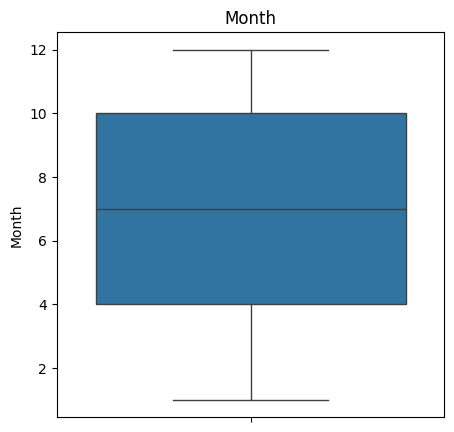

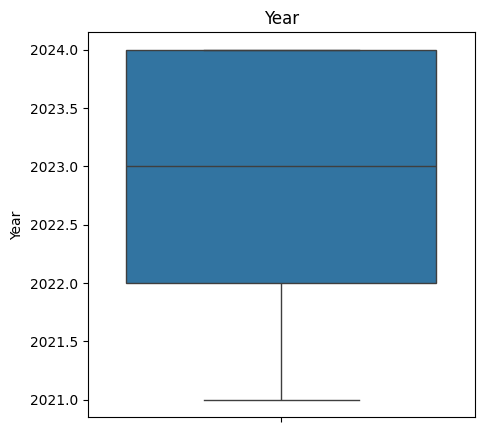

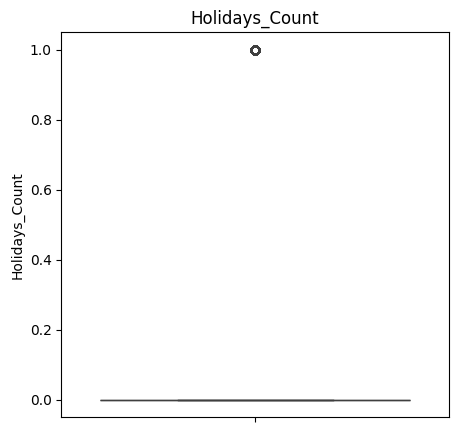

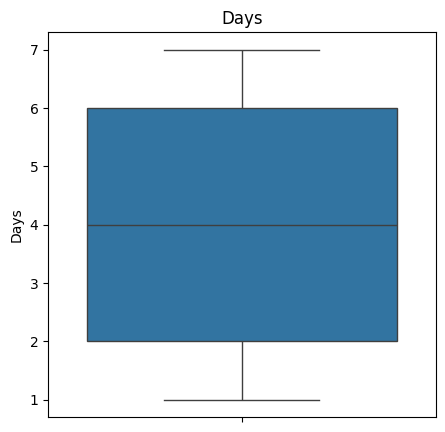

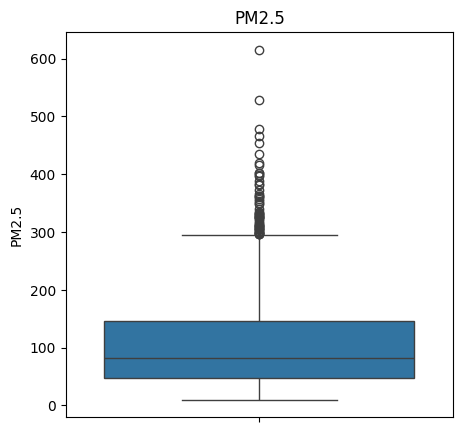

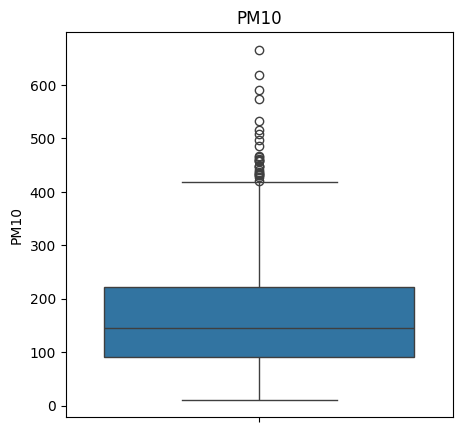

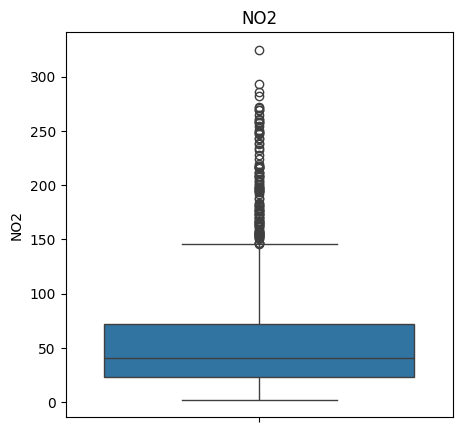

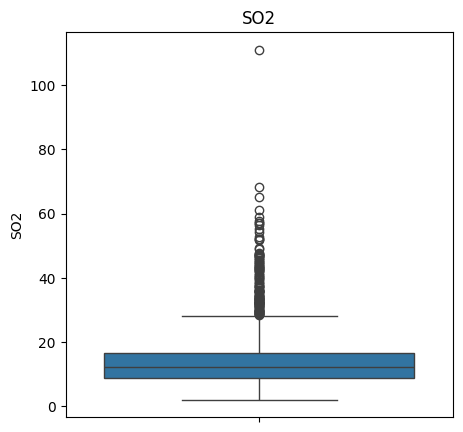

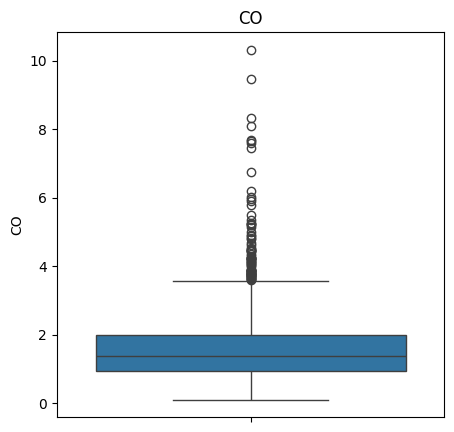

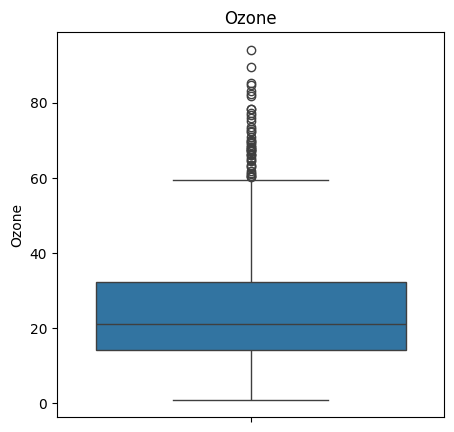

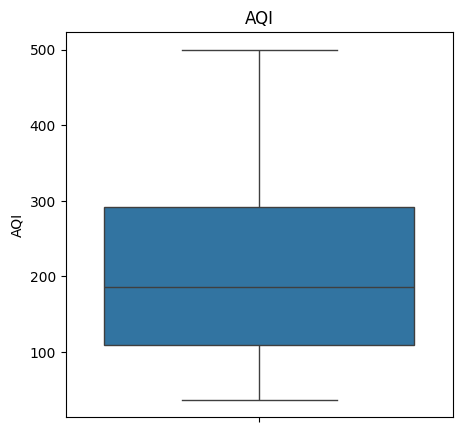

In [164]:
for col in numeric_col:
    plt.figure(figsize=(5,5))
    sns.boxplot(dataset[col])
    plt.title(col)
    plt.show()

<i>Understanding normal distribution of data</i>

- Later half of the dataset is skewed

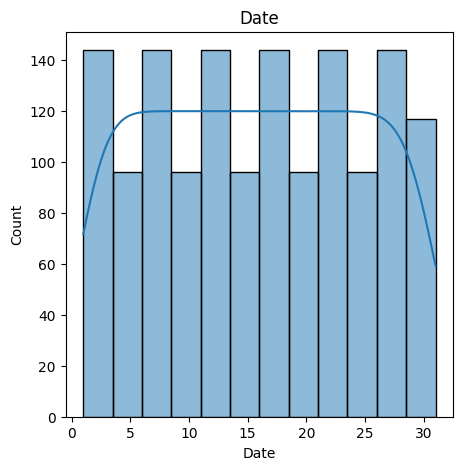

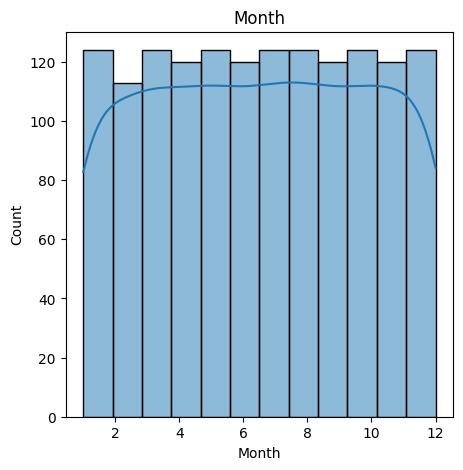

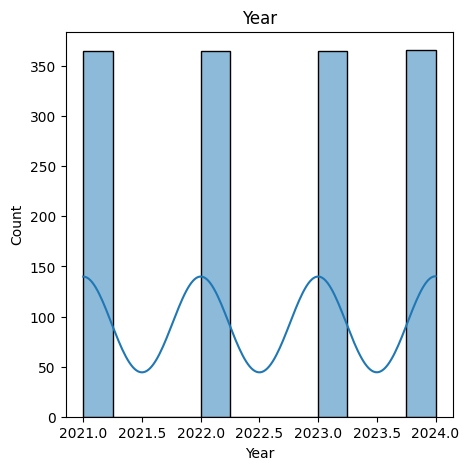

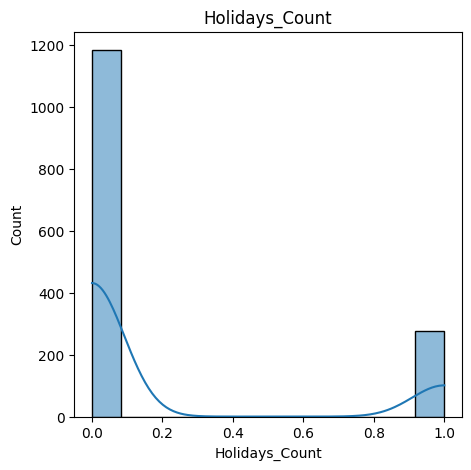

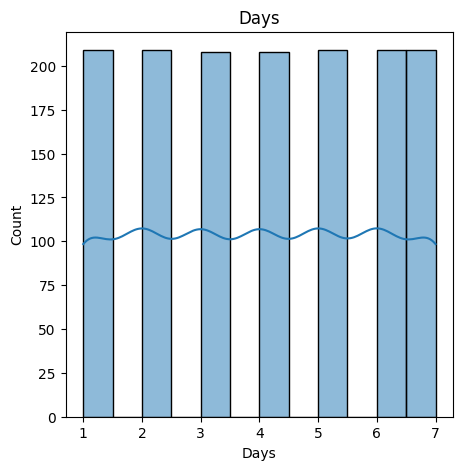

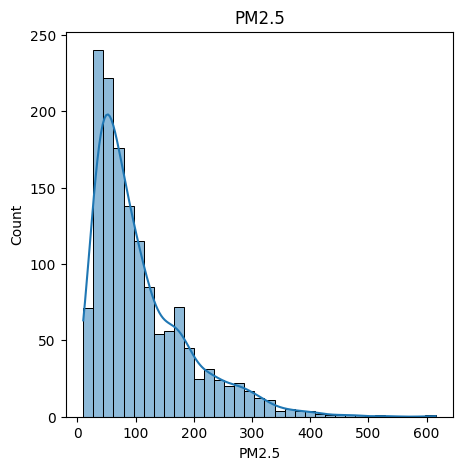

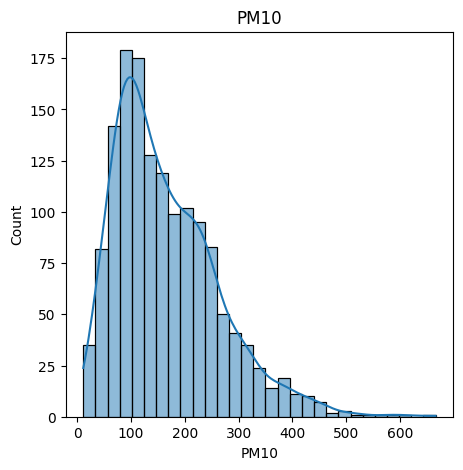

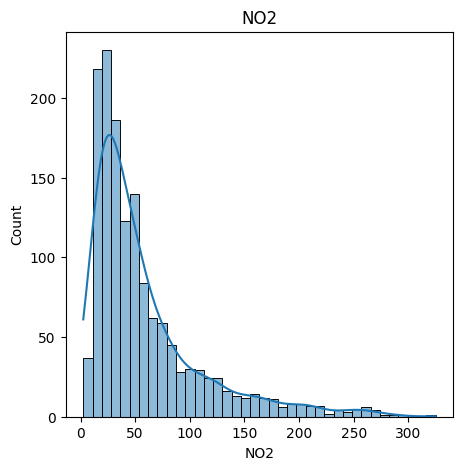

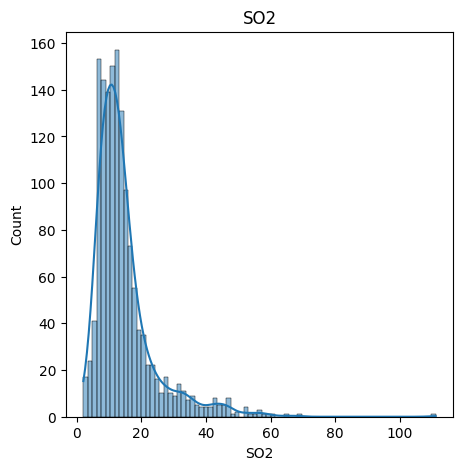

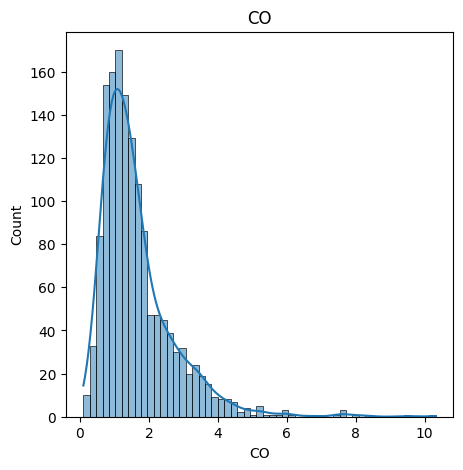

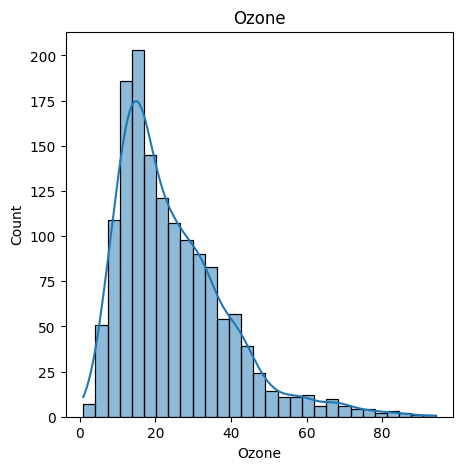

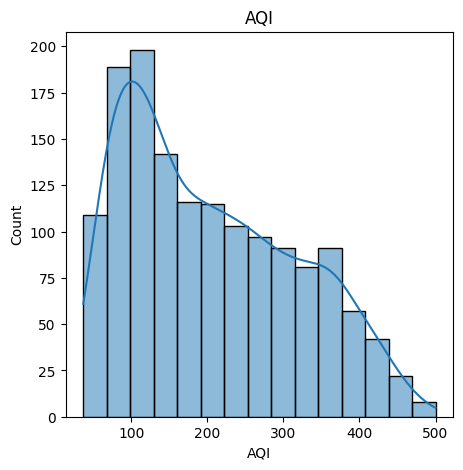

In [165]:
for col in numeric_col:
    plt.figure(figsize=(5,5))
    sns.histplot(dataset[col],kde=True)
    plt.title(col)
    plt.show()

<i>Dropping unnecessary columns using the ANOVA result</i>

- Dropped unnecessary columns based on if p-values > 0.05

In [166]:
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm

for col in numeric_col:
    if col!="AQI":
        model=sm.ols(f"AQI~Q('{col}')",data=dataset).fit()
        anova=anova_lm(model,typ=2)
        print(f"For {col}, the ANOVA result is:")
        print(anova)
        print()

For Date, the ANOVA result is:
                 sum_sq      df        F    PR(>F)
Q('Date')  8.515471e+04     1.0  6.82962  0.009058
Residual   1.819146e+07  1459.0      NaN       NaN

For Month, the ANOVA result is:
                  sum_sq      df         F    PR(>F)
Q('Month')  9.388503e+01     1.0  0.007495  0.931023
Residual    1.827652e+07  1459.0       NaN       NaN

For Year, the ANOVA result is:
                 sum_sq      df         F    PR(>F)
Q('Year')  1.019676e+05     1.0  8.185621  0.004283
Residual   1.817464e+07  1459.0       NaN       NaN

For Holidays_Count, the ANOVA result is:
                           sum_sq      df         F    PR(>F)
Q('Holidays_Count')  6.013318e+02     1.0  0.048005  0.826602
Residual             1.827601e+07  1459.0       NaN       NaN

For Days, the ANOVA result is:
                 sum_sq      df         F    PR(>F)
Q('Days')  3.294227e+03     1.0  0.263022  0.608129
Residual   1.827332e+07  1459.0       NaN       NaN

For PM2.5, the ANOV

In [167]:
dataset=dataset.drop(["Date","Holidays_Count","Days"],axis="columns")

- Updated dataset

In [168]:
dataset

,Month,Year,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,2021,363.12,459.14,13.24,21.39,6.75,8.54,432
1,1,2021,260.94,325.94,12.76,20.41,4.45,6.77,418
2,1,2021,117.07,144.22,11.25,12.43,3.13,6.04,306
3,1,2021,80.38,109.95,14.40,11.05,3.00,6.78,138
4,1,2021,60.66,83.23,13.28,11.22,2.75,6.33,129
...,...,...,...,...,...,...,...,...,...
1456,12,2024,154.11,186.61,77.55,17.42,1.39,14.23,357
1457,12,2024,93.38,119.11,68.71,17.14,1.24,14.05,143
1458,12,2024,98.52,128.91,38.12,17.84,0.77,14.63,254
1459,12,2024,94.41,121.45,32.22,13.27,0.96,15.03,178


<i>Heatmap</i>

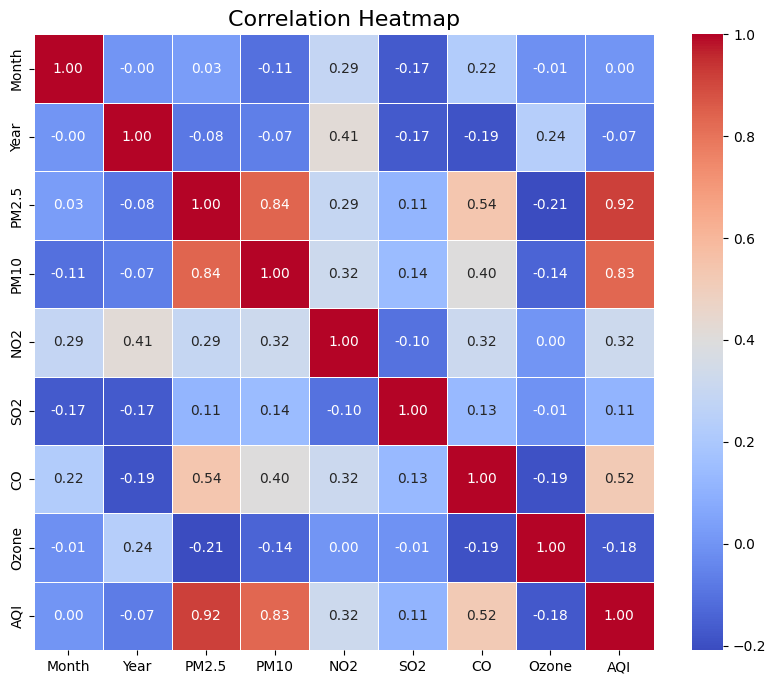

In [169]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    dataset.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

<i>Splitting the dataset into Matrix of Features (X) and Dependent Variable Vector (y)</i>

In [170]:
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

<i>Splitting the dataset into training and test set</i>

In [171]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

<i>Feature scaling</i>

- Used standard scaler because of the "Year" column

In [172]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

2.<u>Model building</u>

<b>a. Multiple Linear Regression</b>

<i>Model building</i>

In [173]:
from sklearn.linear_model import LinearRegression

regression1=LinearRegression()
regression1.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


<i>Predicting the values for the training and the test set</i>

In [174]:
y_pred_train=regression1.predict(X_train)
y_pred_test=regression1.predict(X_test)

print("For the training set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train.reshape(len(y_pred_train),1)),axis=1))
print()

print("For the test set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test.reshape(len(y_pred_test),1)),axis=1))

For the training set:
[Actual_Values Observed_Values]
[[ 64.    98.08]
 [140.   167.62]
 [136.   153.04]
 ...
 [121.   136.86]
 [106.   121.09]
 [233.   187.67]]

For the test set:
[Actual_Values Observed_Values]
[[124.   123.04]
 [229.   251.07]
 [148.   169.  ]
 [ 99.   132.59]
 [229.   249.56]
 [403.   433.21]
 [335.   296.95]
 [160.   172.45]
 [259.   276.55]
 [340.   303.72]
 [ 82.    90.06]
 [422.   480.78]
 [135.   114.17]
 [ 77.    88.79]
 [243.   196.3 ]
 [ 56.   121.68]
 [ 73.    82.11]
 [187.   155.81]
 [362.   403.65]
 [281.   280.54]
 [172.   158.86]
 [136.   159.96]
 [305.   248.66]
 [ 77.    97.01]
 [100.   116.68]
 [ 87.   120.91]
 [102.   103.17]
 [346.   265.17]
 [174.   162.47]
 [122.   139.43]
 [314.   205.7 ]
 [377.   387.69]
 [325.   229.58]
 [129.   145.77]
 [304.   254.83]
 [ 69.   112.92]
 [345.   252.73]
 [257.   180.34]
 [340.   260.21]
 [259.   223.7 ]
 [189.   198.21]
 [261.   258.48]
 [300.   265.98]
 [418.   404.81]
 [130.   127.65]
 [419.   384.64]
 [309

<i>Graphical Representation</i>

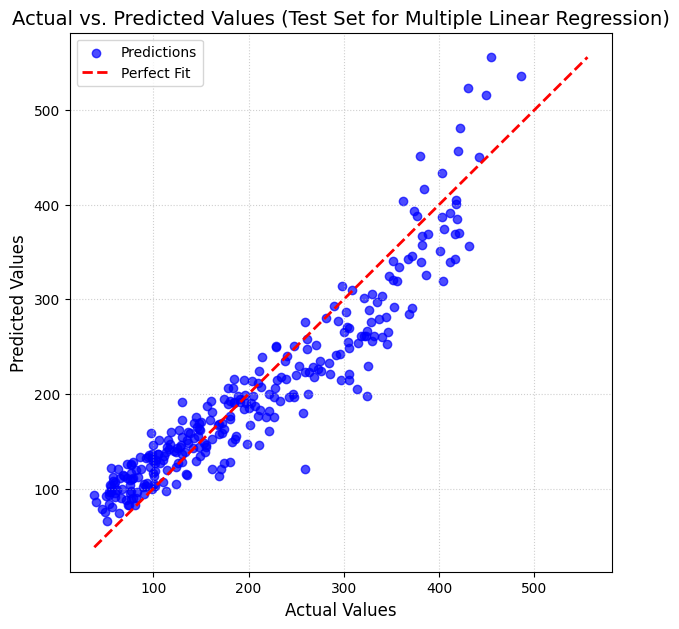

In [175]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, color='blue', alpha=0.7, label='Predictions')

max_val = max(max(y_test), max(y_pred_test))
min_val = min(min(y_test), min(y_pred_test))

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title('Actual vs. Predicted Values (Test Set for Multiple Linear Regression)', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

<i>Accuracy of the model</i>

In [176]:
from sklearn.metrics import r2_score

print(f"R2-score for the training set is: {r2_score(y_train,y_pred_train)*100:.2f}%")

print(f"R2-score for the test set is: {r2_score(y_test,y_pred_test)*100:.2f}%")

R2-score for the training set is: 85.12%
R2-score for the test set is: 87.37%


<i>Error in the model</i>

In [177]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_train=mean_squared_error(y_train,y_pred_train)
mse_test=mean_squared_error(y_test,y_pred_test)

rmse_train=np.sqrt(mse_train)
rmse_test=np.sqrt(mse_test)

mae_train=mean_absolute_error(y_train,y_pred_train)
mae_test=mean_absolute_error(y_test,y_pred_test)

print("For training set:")
print(f"Root Mean Squared Error: {rmse_train:.2f}")
print(f"Mean Absolute Error: {mae_train:.2f}")
print()

print("For test set:")
print(f"Root Mean Squared Error: {rmse_test:.2f}")
print(f"Mean Absolute Error: {mae_test:.2f}")

For training set:
Root Mean Squared Error: 43.05
Mean Absolute Error: 33.37

For test set:
Root Mean Squared Error: 40.06
Mean Absolute Error: 32.38


<i>Cross-Validation</i>

In [178]:
from sklearn.model_selection import cross_val_score

cv=cross_val_score(regression1,X_train,y_train,cv=10)

print(f"Training accuracy after cross-validation is: {cv.mean()*100:.2f}%")

Training accuracy after cross-validation is: 84.72%


<b>b. Polynomial Linear Regression</b>

<i>Finding best degree</i>

In [179]:
from sklearn.preprocessing import PolynomialFeatures
import pprint

dic={}
for i in range(1,11):
    poly_fea=PolynomialFeatures(degree=i)
    X_train_poly=poly_fea.fit_transform(X_train)
    X_test_poly=poly_fea.transform(X_test)
    
    dummy=LinearRegression()
    dummy.fit(X_train_poly,y_train)
    
    y_pred_train_dummy=dummy.predict(X_train_poly)
    y_pred_test_dummy=dummy.predict(X_test_poly)
    
    r2_train_dummy=r2_score(y_train,y_pred_train_dummy)
    r2_test_dummy=r2_score(y_test,y_pred_test_dummy)
    
    dic[i]=[f"Training Accuracy: {r2_train_dummy:.2f}, Test Accuracy: {r2_test_dummy:.2f}"]
    
pprint.pprint(dic)

{1: ['Training Accuracy: 0.85, Test Accuracy: 0.87'],
 2: ['Training Accuracy: 0.93, Test Accuracy: 0.93'],
 3: ['Training Accuracy: 0.95, Test Accuracy: 0.93'],
 4: ['Training Accuracy: 0.97, Test Accuracy: -2.33'],
 5: ['Training Accuracy: 1.00, Test Accuracy: -21454.13'],
 6: ['Training Accuracy: 1.00, Test Accuracy: -2799.22'],
 7: ['Training Accuracy: 1.00, Test Accuracy: -10382.63'],
 8: ['Training Accuracy: 1.00, Test Accuracy: -137759.03'],
 9: ['Training Accuracy: 1.00, Test Accuracy: -800827.16'],
 10: ['Training Accuracy: 1.00, Test Accuracy: -57491003.24']}


<i>Making polynomial features</i>

- We choose degree = 3, since it has the highest training and test accuracy

In [180]:
from sklearn.preprocessing import PolynomialFeatures

poly_fea=PolynomialFeatures(degree=3)
X_train_poly=poly_fea.fit_transform(X_train)
X_test_poly=poly_fea.transform(X_test)

<i>Model building</i>

In [181]:
from sklearn.linear_model import LinearRegression

regression2=LinearRegression()
regression2.fit(X_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


<i>Predicting the values for the training and the test set</i>

In [182]:
y_pred_train2=regression2.predict(X_train_poly)
y_pred_test2=regression2.predict(X_test_poly)

print("For the training set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train2.reshape(len(y_pred_train2),1)),axis=1))
print()

print("For the test set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test2.reshape(len(y_pred_test2),1)),axis=1))

For the training set:
[Actual_Values Observed_Values]
[[ 64.    79.72]
 [140.   148.24]
 [136.   146.93]
 ...
 [121.   115.66]
 [106.    94.5 ]
 [233.   220.36]]

For the test set:
[Actual_Values Observed_Values]
[[124.   104.47]
 [229.   252.06]
 [148.   163.18]
 [ 99.   119.25]
 [229.   280.45]
 [403.   435.7 ]
 [335.   350.67]
 [160.   166.59]
 [259.   260.17]
 [340.   335.51]
 [ 82.    74.7 ]
 [422.   427.68]
 [135.   111.69]
 [ 77.    31.56]
 [243.   231.09]
 [ 56.    90.32]
 [ 73.    59.  ]
 [187.   157.59]
 [362.   378.68]
 [281.   280.44]
 [172.   159.54]
 [136.   166.34]
 [305.   283.07]
 [ 77.    79.99]
 [100.    88.33]
 [ 87.   137.83]
 [102.    84.13]
 [346.   327.28]
 [174.   180.59]
 [122.   130.97]
 [314.   272.94]
 [377.   373.75]
 [325.   300.85]
 [129.   122.82]
 [304.   279.88]
 [ 69.    87.89]
 [345.   302.46]
 [257.   188.63]
 [340.   286.63]
 [259.   255.14]
 [189.   238.72]
 [261.   263.46]
 [300.   319.47]
 [418.   402.96]
 [130.   109.86]
 [419.   437.05]
 [309

<i>Graphical Representation</i>

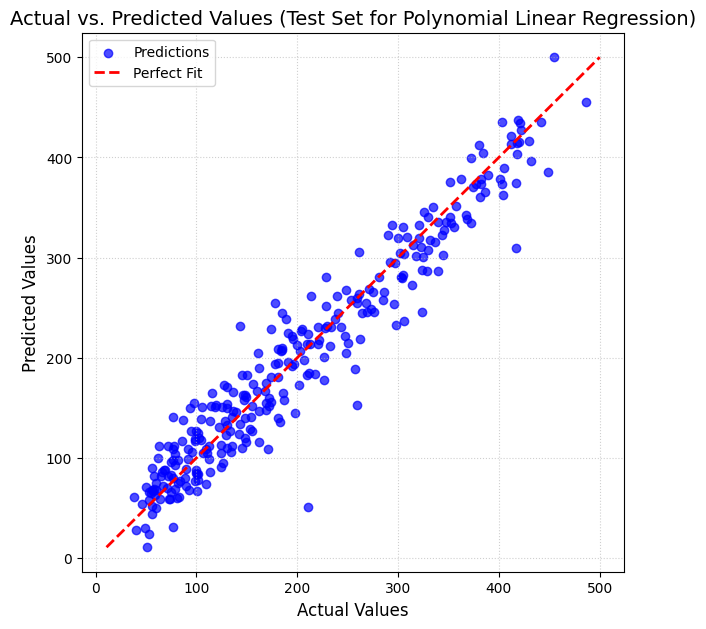

In [183]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test2, color='blue', alpha=0.7, label='Predictions')

max_val = max(max(y_test), max(y_pred_test2))
min_val = min(min(y_test), min(y_pred_test2))

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title('Actual vs. Predicted Values (Test Set for Polynomial Linear Regression)', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

<i>Accuracy of the model</i>

In [184]:
from sklearn.metrics import r2_score

print(f"R2-score for the training set is: {r2_score(y_train,y_pred_train2)*100:.2f}%")

print(f"R2-score for the test set is: {r2_score(y_test,y_pred_test2)*100:.2f}%")

R2-score for the training set is: 94.73%
R2-score for the test set is: 92.97%


<i>Error of the model</i>

In [185]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_train2=mean_squared_error(y_train,y_pred_train2)
mse_test2=mean_squared_error(y_test,y_pred_test2)

rmse_train2=np.sqrt(mse_train2)
rmse_test2=np.sqrt(mse_test2)

mae_train2=mean_absolute_error(y_train,y_pred_train2)
mae_test2=mean_absolute_error(y_test,y_pred_test2)

print("For training set:")
print(f"Root Mean Squared Error: {rmse_train2:.2f}")
print(f"Mean Absolute Error: {mae_train2:.2f}")
print()

print("For test set:")
print(f"Root Mean Squared Error: {rmse_test2:.2f}")
print(f"Mean Absolute Error: {mae_test2:.2f}")

For training set:
Root Mean Squared Error: 25.61
Mean Absolute Error: 19.34

For test set:
Root Mean Squared Error: 29.89
Mean Absolute Error: 22.77


<i>Cross-Validation</i>

In [186]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=0)
fold_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    
    poly_fea = PolynomialFeatures(degree=3)
    X_tr_poly = poly_fea.fit_transform(X_tr)
    X_val_poly = poly_fea.transform(X_val)
    
    model = LinearRegression()
    model.fit(X_tr_poly, y_tr)
    
    score = r2_score(y_val, model.predict(X_val_poly))
    fold_scores.append(score)

print(f"Mean CV R² for degree 3: {np.mean(fold_scores)*100:.2f}%")

Mean CV R² for degree 3: 87.86%


<b>c. Support Vector Regression</b>

<i>Model building</i>

In [187]:
from sklearn.svm import SVR

regression3=SVR(kernel="rbf")
regression3.fit(X_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


<i>Predicting the values for the training and the test set</i>

In [188]:
y_pred_train3=regression3.predict(X_train)
y_pred_test3=regression3.predict(X_test)

print("For the training set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train3.reshape(len(y_pred_train3),1)),axis=1))
print()

print("For the test set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test3.reshape(len(y_pred_test3),1)),axis=1))

For the training set:
[Actual_Values Observed_Values]
[[ 64.   108.67]
 [140.   196.61]
 [136.   144.7 ]
 ...
 [121.   155.87]
 [106.   136.32]
 [233.   171.95]]

For the test set:
[Actual_Values Observed_Values]
[[124.   110.54]
 [229.   254.49]
 [148.   166.55]
 [ 99.   144.76]
 [229.   252.02]
 [403.   304.62]
 [335.   265.76]
 [160.   151.98]
 [259.   251.62]
 [340.   281.99]
 [ 82.   117.22]
 [422.   290.54]
 [135.   143.72]
 [ 77.    99.79]
 [243.   224.5 ]
 [ 56.   176.2 ]
 [ 73.   111.15]
 [187.   189.01]
 [362.   281.11]
 [281.   269.85]
 [172.   174.09]
 [136.   165.08]
 [305.   248.63]
 [ 77.   171.99]
 [100.   117.52]
 [ 87.   179.63]
 [102.   121.12]
 [346.   246.4 ]
 [174.   170.27]
 [122.   125.57]
 [314.   186.61]
 [377.   279.81]
 [325.   230.97]
 [129.   195.39]
 [304.   244.67]
 [ 69.   112.95]
 [345.   245.45]
 [257.   159.05]
 [340.   243.06]
 [259.   232.73]
 [189.   215.32]
 [261.   249.31]
 [300.   258.3 ]
 [418.   295.56]
 [130.   136.3 ]
 [419.   242.51]
 [309

<i>Graphical Representation</i>

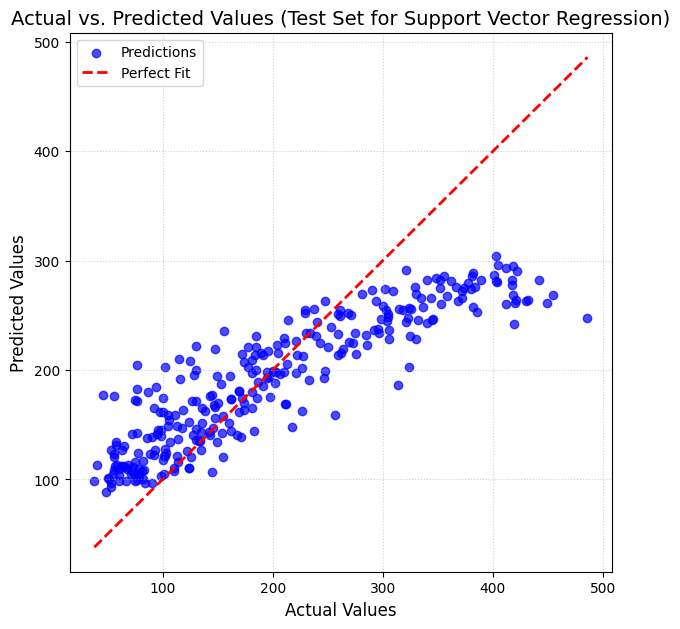

In [189]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test3, color='blue', alpha=0.7, label='Predictions')

max_val = max(max(y_test), max(y_pred_test3))
min_val = min(min(y_test), min(y_pred_test3))

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title('Actual vs. Predicted Values (Test Set for Support Vector Regression)', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

<i>Accuracy of the model</i>

In [190]:
from sklearn.metrics import r2_score

print(f"R2-score for the training set is: {r2_score(y_train,y_pred_train3)*100:.2f}")

print(f"R2-score for the test set is: {r2_score(y_test,y_pred_test3)*100:.2f}")

R2-score for the training set is: 66.19
R2-score for the test set is: 66.00


<i>Error of the model</i>

In [191]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_train3=mean_squared_error(y_train,y_pred_train3)
mse_test3=mean_squared_error(y_test,y_pred_test3)

rmse_train3=np.sqrt(mse_train3)
rmse_test3=np.sqrt(mse_test3)

mae_train3=mean_absolute_error(y_train,y_pred_train3)
mae_test3=mean_absolute_error(y_test,y_pred_test3)

print("For training set:")
print(f"Root Mean Squared Error: {rmse_train3:.2f}")
print(f"Mean Absolute Error: {mae_train3:.2f}")
print()

print("For test set:")
print(f"Root Mean Squared Error: {rmse_test3:.2f}")
print(f"Mean Absolute Error: {mae_test3:.2f}")

For training set:
Root Mean Squared Error: 64.89
Mean Absolute Error: 50.47

For test set:
Root Mean Squared Error: 65.73
Mean Absolute Error: 50.80


<i>Cross-Validation</i>

In [192]:
from sklearn.model_selection import cross_val_score

cv3=cross_val_score(regression3,X_train,y_train,cv=10)

print(f"Training accuracy after cross-validation is: {cv3.mean()*100:.2f}%")

Training accuracy after cross-validation is: 62.91%


<b>d. Decision Tree Regression</b>

<i>Finding best max-depth</i>

In [193]:
from sklearn.tree import DecisionTreeRegressor

dic1={}
for i in range(1,11):
    dummy1=DecisionTreeRegressor(max_depth=i,random_state=0)
    dummy1.fit(X_train,y_train)
    
    y_pred_train_dummy1=dummy1.predict(X_train)
    y_pred_test_dummy1=dummy1.predict(X_test)
    
    r2_train_dummy1=r2_score(y_train,y_pred_train_dummy1)
    r2_test_dummy1=r2_score(y_test,y_pred_test_dummy1)
    
    dic1[i]=[f"Training Accuracy: {r2_train_dummy1:.2f}, Test Accuracy: {r2_test_dummy1:.2f}"]
    
pprint.pprint(dic1)

{1: ['Training Accuracy: 0.70, Test Accuracy: 0.73'],
 2: ['Training Accuracy: 0.86, Test Accuracy: 0.87'],
 3: ['Training Accuracy: 0.91, Test Accuracy: 0.92'],
 4: ['Training Accuracy: 0.93, Test Accuracy: 0.92'],
 5: ['Training Accuracy: 0.94, Test Accuracy: 0.93'],
 6: ['Training Accuracy: 0.95, Test Accuracy: 0.93'],
 7: ['Training Accuracy: 0.96, Test Accuracy: 0.93'],
 8: ['Training Accuracy: 0.97, Test Accuracy: 0.93'],
 9: ['Training Accuracy: 0.98, Test Accuracy: 0.92'],
 10: ['Training Accuracy: 0.98, Test Accuracy: 0.91']}


<i>Model building</i>

- We choose max-depth = 9 as it has the highest training and test accuracy

In [194]:
from sklearn.tree import DecisionTreeRegressor

regression4=DecisionTreeRegressor(max_depth=9,random_state=0)
regression4.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


<i>Predicting the values for the training and the test set</i>

In [195]:
y_pred_train4=regression4.predict(X_train)
y_pred_test4=regression4.predict(X_test)

print("For the training set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train4.reshape(len(y_pred_train4),1)),axis=1))
print()

print("For the test set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test4.reshape(len(y_pred_test4),1)),axis=1))

For the training set:
[Actual_Values Observed_Values]
[[ 64.    65.72]
 [140.   152.6 ]
 [136.   133.21]
 ...
 [121.   133.21]
 [106.   114.98]
 [233.   243.25]]

For the test set:
[Actual_Values Observed_Values]
[[124.   114.98]
 [229.   254.25]
 [148.   169.67]
 [ 99.   120.73]
 [229.   254.25]
 [403.   413.89]
 [335.   317.71]
 [160.   156.75]
 [259.   294.64]
 [340.   295.12]
 [ 82.    78.46]
 [422.   413.89]
 [135.   117.11]
 [ 77.    65.72]
 [243.   245.  ]
 [ 56.   126.  ]
 [ 73.    78.46]
 [187.   144.41]
 [362.   416.5 ]
 [281.   294.64]
 [172.   133.21]
 [136.   152.6 ]
 [305.   279.29]
 [ 77.    77.83]
 [100.    65.72]
 [ 87.   126.  ]
 [102.    74.  ]
 [346.   295.12]
 [174.   114.  ]
 [122.   102.84]
 [314.   299.17]
 [377.   411.  ]
 [325.   299.17]
 [129.   119.  ]
 [304.   294.64]
 [ 69.    65.72]
 [345.   294.64]
 [257.   196.22]
 [340.   294.64]
 [259.   234.5 ]
 [189.   237.  ]
 [261.   239.89]
 [300.   317.71]
 [418.   416.5 ]
 [130.   102.84]
 [419.   374.3 ]
 [309

<i>Graphical Representation</i>

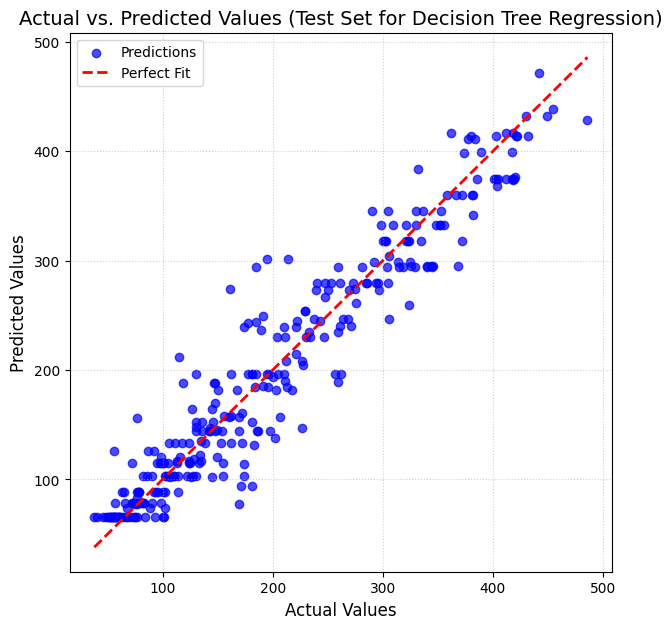

In [196]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test4, color='blue', alpha=0.7, label='Predictions')

max_val = max(max(y_test), max(y_pred_test4))
min_val = min(min(y_test), min(y_pred_test4))

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title('Actual vs. Predicted Values (Test Set for Decision Tree Regression)', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

<i>Accuracy of the model</i>

In [197]:
from sklearn.metrics import r2_score

print(f"R2-score for the training set is: {r2_score(y_train,y_pred_train4)*100:.2f}%")

print(f"R2-score for the test set is: {r2_score(y_test,y_pred_test4)*100:.2f}%")

R2-score for the training set is: 97.83%
R2-score for the test set is: 92.04%


<i>Plotting decision tree</i>

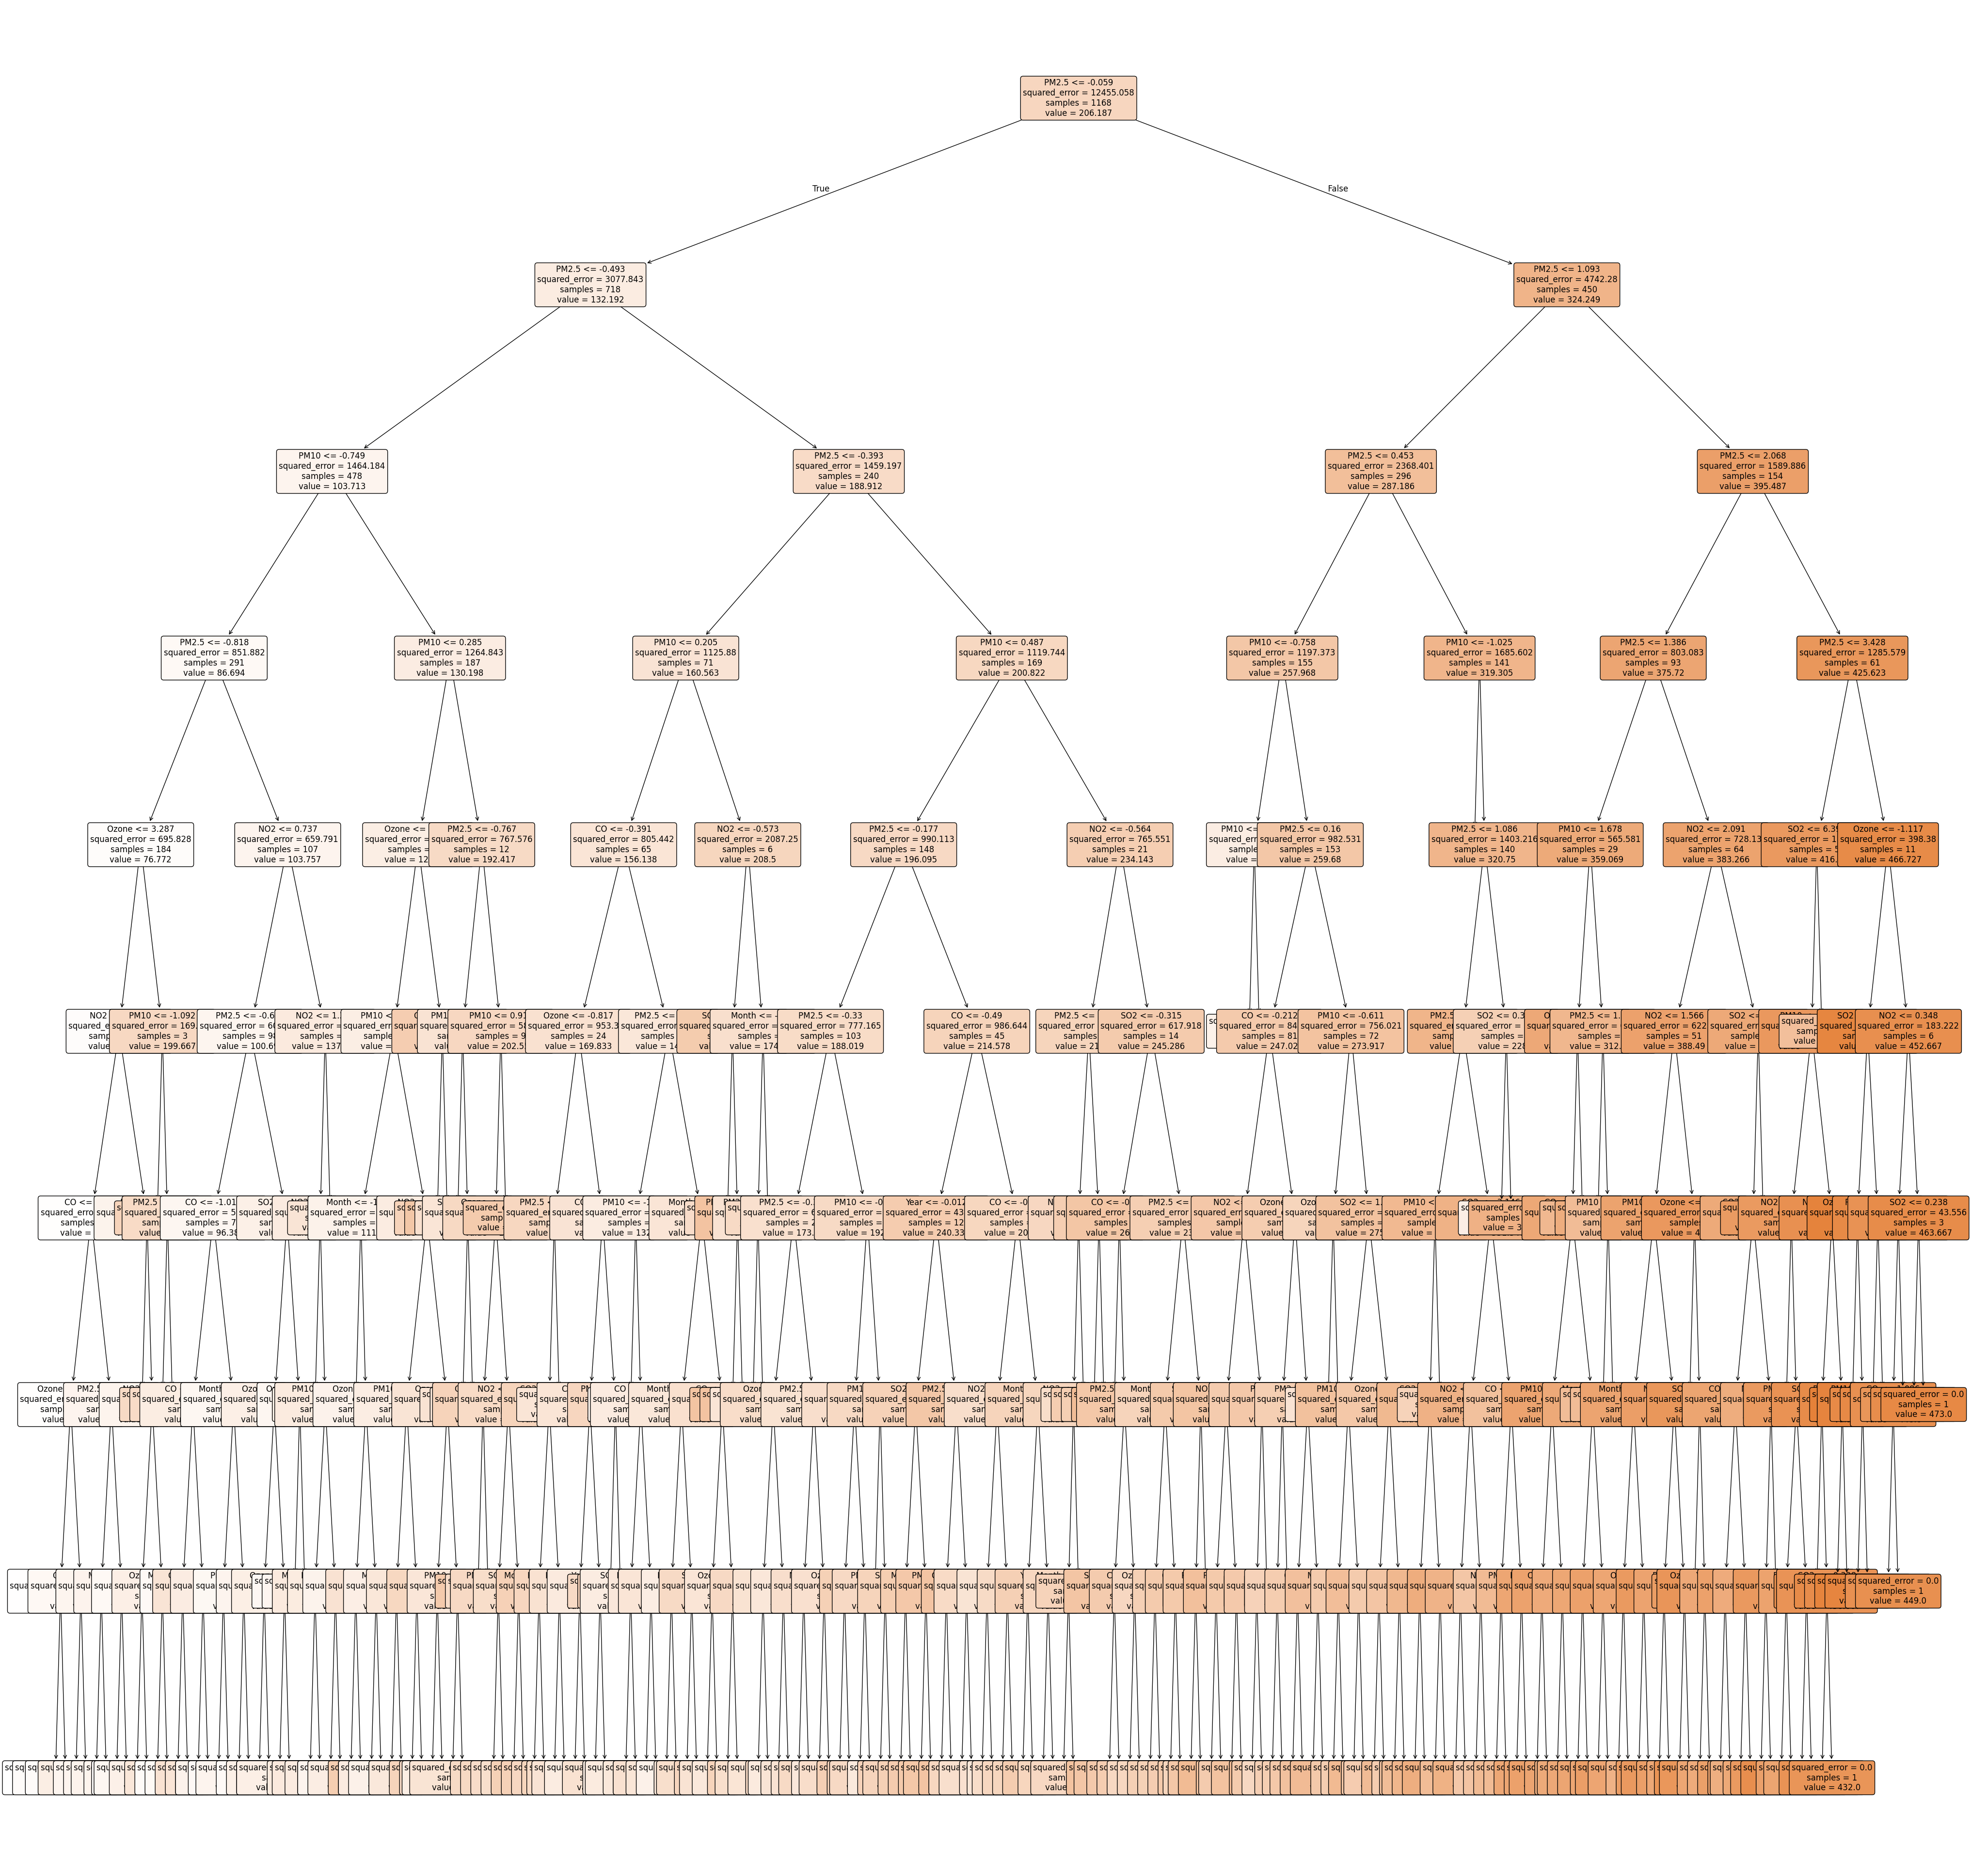

In [198]:
from sklearn.tree import plot_tree

plt.figure(figsize=(50,50))
plot_tree(
    regression4,
    feature_names=["Month","Year","PM2.5","PM10","NO2","SO2","CO","Ozone"],
    class_names=["AQI"],
    filled=True,
    rounded=True,
    fontsize=12
)

plt.show()

<i>Error of the model</i>

In [199]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_train4=mean_squared_error(y_train,y_pred_train4)
mse_test4=mean_squared_error(y_test,y_pred_test4)

rmse_train4=np.sqrt(mse_train4)
rmse_test4=np.sqrt(mse_test4)

mae_train4=mean_absolute_error(y_train,y_pred_train4)
mae_test4=mean_absolute_error(y_test,y_pred_test4)

print("For training set:")
print(f"Root Mean Squared Error: {rmse_train4:.2f}")
print(f"Mean Absolute Error: {mae_train4:.2f}")
print()

print("For test set:")
print(f"Root Mean Squared Error: {rmse_test4:.2f}")
print(f"Mean Absolute Error: {mae_test4:.2f}")

For training set:
Root Mean Squared Error: 16.45
Mean Absolute Error: 11.02

For test set:
Root Mean Squared Error: 31.81
Mean Absolute Error: 23.46


<i>Cross-Validation</i>

In [200]:
from sklearn.model_selection import cross_val_score

cv4=cross_val_score(regression4,X_train,y_train,cv=10)

print(f"Training accuracy after cross-validation is: {cv4.mean()*100:.2f}%")

Training accuracy after cross-validation is: 88.70%


<b>e. Random Forest Regression</b>

<i>Finding the best number of estimators</i>

In [201]:
from sklearn.ensemble import RandomForestRegressor

dic2={}
for i in range(100,1001,100):
    dummy2=RandomForestRegressor(n_estimators=i,random_state=0)
    dummy2.fit(X_train,y_train)
    
    y_pred_train_dummy2=dummy2.predict(X_train)
    y_pred_test_dummy2=dummy2.predict(X_test)
    
    r2_train_dummy2=r2_score(y_train,y_pred_train_dummy2)
    r2_test_dummy2=r2_score(y_test,y_pred_test_dummy2)
    
    dic2[i]=[f"Training Accuracy: {r2_train_dummy2:.2f}, Test Accuracy: {r2_test_dummy2:.2f}"]
    
pprint.pprint(dic2)

{100: ['Training Accuracy: 0.99, Test Accuracy: 0.95'],
 200: ['Training Accuracy: 0.99, Test Accuracy: 0.95'],
 300: ['Training Accuracy: 0.99, Test Accuracy: 0.95'],
 400: ['Training Accuracy: 0.99, Test Accuracy: 0.95'],
 500: ['Training Accuracy: 0.99, Test Accuracy: 0.95'],
 600: ['Training Accuracy: 0.99, Test Accuracy: 0.95'],
 700: ['Training Accuracy: 0.99, Test Accuracy: 0.95'],
 800: ['Training Accuracy: 0.99, Test Accuracy: 0.95'],
 900: ['Training Accuracy: 0.99, Test Accuracy: 0.95'],
 1000: ['Training Accuracy: 0.99, Test Accuracy: 0.95']}


<i>Model building</i>

- We choose the number of estimators as 100, as there aren't really any differences in the accuracies of the training set and the test set

In [202]:
from sklearn.ensemble import RandomForestRegressor

regression5=RandomForestRegressor(n_estimators=100,random_state=0)
regression5.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<i>Predicting the values for the training and the test set</i>

In [203]:
y_pred_train5=regression5.predict(X_train)
y_pred_test5=regression5.predict(X_test)

print("For the training set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train5.reshape(len(y_pred_train5),1)),axis=1))
print()

print("For the test set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test5.reshape(len(y_pred_test5),1)),axis=1))

For the training set:
[Actual_Values Observed_Values]
[[ 64.    63.58]
 [140.   147.52]
 [136.   136.62]
 ...
 [121.   121.96]
 [106.   104.24]
 [233.   237.8 ]]

For the test set:
[Actual_Values Observed_Values]
[[124.   111.87]
 [229.   249.56]
 [148.   157.38]
 [ 99.   118.67]
 [229.   242.48]
 [403.   406.63]
 [335.   322.53]
 [160.   166.06]
 [259.   290.04]
 [340.   323.16]
 [ 82.    73.4 ]
 [422.   433.05]
 [135.   113.02]
 [ 77.    63.43]
 [243.   205.21]
 [ 56.    85.98]
 [ 73.    71.9 ]
 [187.   155.92]
 [362.   391.82]
 [281.   292.63]
 [172.   139.28]
 [136.   158.62]
 [305.   281.51]
 [ 77.    80.87]
 [100.    78.99]
 [ 87.    98.52]
 [102.    84.67]
 [346.   310.26]
 [174.   157.19]
 [122.   115.4 ]
 [314.   289.55]
 [377.   366.21]
 [325.   284.86]
 [129.   112.72]
 [304.   286.  ]
 [ 69.    78.4 ]
 [345.   291.34]
 [257.   195.54]
 [340.   283.53]
 [259.   248.24]
 [189.   231.87]
 [261.   271.65]
 [300.   296.2 ]
 [418.   407.61]
 [130.   105.33]
 [419.   387.96]
 [309

<i>Graphical Representation</i>

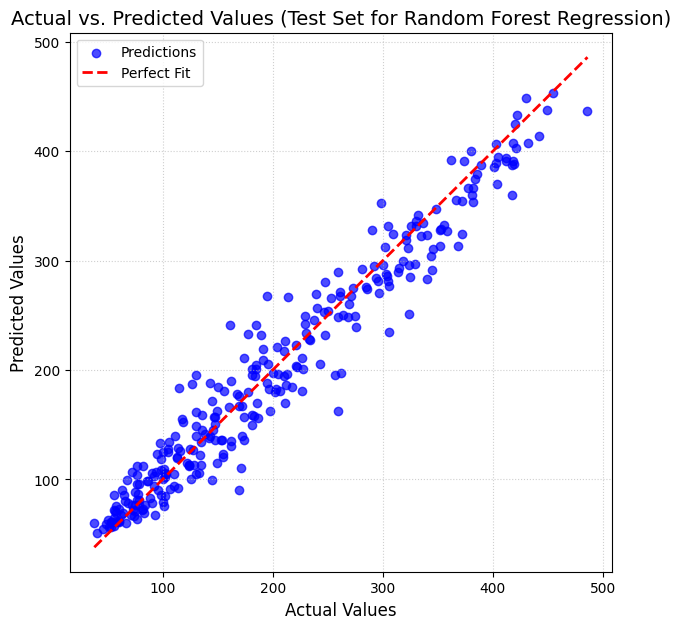

In [204]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test5, color='blue', alpha=0.7, label='Predictions')

max_val = max(max(y_test), max(y_pred_test5))
min_val = min(min(y_test), min(y_pred_test5))

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title('Actual vs. Predicted Values (Test Set for Random Forest Regression)', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

<i>Accuracy of the model</i>

In [205]:
from sklearn.metrics import r2_score

print(f"R2-score for the training set is: {r2_score(y_train,y_pred_train5)*100:.2f}")

print(f"R2-score for the test set is: {r2_score(y_test,y_pred_test5)*100:.2f}")

R2-score for the training set is: 98.96
R2-score for the test set is: 94.74


<i>Error in the model</i>

In [206]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_train5=mean_squared_error(y_train,y_pred_train5)
mse_test5=mean_squared_error(y_test,y_pred_test5)

rmse_train5=np.sqrt(mse_train5)
rmse_test5=np.sqrt(mse_test5)

mae_train5=mean_absolute_error(y_train,y_pred_train5)
mae_test5=mean_absolute_error(y_test,y_pred_test5)

print("For training set:")
print(f"Root Mean Squared Error: {rmse_train5:.2f}")
print(f"Mean Absolute Error: {mae_train5:.2f}")
print()

print("For test set:")
print(f"Root Mean Squared Error: {rmse_test5:.2f}")
print(f"Mean Absolute Error: {mae_test5:.2f}")

For training set:
Root Mean Squared Error: 11.39
Mean Absolute Error: 7.99

For test set:
Root Mean Squared Error: 25.85
Mean Absolute Error: 19.85


<i>Cross-Validation</i>

In [207]:
from sklearn.model_selection import cross_val_score

cv5=cross_val_score(regression5,X_train,y_train,cv=10)

print(f"Training accuracy after cross-validation is: {cv5.mean()*100:.2f}%")

Training accuracy after cross-validation is: 92.46%


3.<u>Result</u>

- Model Performance Comparison

| Model | Training R² (%) | Testing R² (%) | RMSE (Train) | RMSE (Test) | MAE (Train) | MAE (Test) | CV_Train (%) |
|---|---:|---:|---:|---:|---:|---:|---:|
| Multiple Linear Regression | 85.12 | 87.37 | 43.05 | 40.06 | 33.37 | 32.38 | 84.72 |
| Polynomial Linear Regression (Degree 3) | 94.73 | 92.97 | 25.61 | 29.89 | 19.34 | 22.77 | 87.86 |
| Support Vector Regression (RBF) | 66.19 | 66.00 | 64.89 | 65.73 | 50.47 | 50.80 | 62.91 |
| Decision Tree Regression | 97.83 | 92.07 | 16.45 | 31.75 | 11.02 | 23.30 | 89.39 | 
| Random Forest Regression | 98.97 | **94.80** | 11.3 | 25.70 | 7.93 | 19.64 | **92.57** |

4.<u>Model deployment</u>

- Deploying "Random Forest Regressor" model for future use

In [208]:
import pickle as pk

with open(r"scaler.pk","wb") as file:
    pk.dump(scaler,file)
    
with open(r"Random_Forest.pk","wb") as file:
    pk.dump(regression5,file)